# EDA ACCIDENTALIDAD MADRID

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

¿En qué franja horaria se producen los accidentes con mayor gravedad (ingreso superior a 24 horas o fallecidos) y qué condiciones (estado meteorológico, tipo de accidente, etc.) pueden influir en ello?”

## 1. Idea general del dataset.

In [ ]:
"""Abrimos el database y le damos un nombre"""
db = pd.read_csv("data/accidentalidad.csv", sep=";", encoding="utf8")


In [86]:
"""Lo analizamos a nivel general"""
db.shape

(49340, 19)

In [87]:
db.columns

Index(['num_expediente', 'fecha', 'hora', 'localizacion', 'numero',
       'cod_distrito', 'distrito', 'tipo_accidente', 'estado_meteorológico',
       'tipo_vehiculo', 'tipo_persona', 'rango_edad', 'sexo', 'cod_lesividad',
       'lesividad', 'coordenada_x_utm', 'coordenada_y_utm', 'positiva_alcohol',
       'positiva_droga'],
      dtype='object')

In [88]:
db.dtypes

num_expediente           object
fecha                    object
hora                     object
localizacion             object
numero                   object
cod_distrito              int64
distrito                 object
tipo_accidente           object
estado_meteorológico     object
tipo_vehiculo            object
tipo_persona             object
rango_edad               object
sexo                     object
cod_lesividad           float64
lesividad                object
coordenada_x_utm        float64
coordenada_y_utm        float64
positiva_alcohol         object
positiva_droga          float64
dtype: object

In [89]:
db.head(5)

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga
0,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,Conductor,De 55 a 59 años,Hombre,2.0,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,N,NaN
1,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,Conductor,De 55 a 59 años,Mujer,14.0,Sin asistencia sanitaria,444913.0,4481427.0,N,NaN
2,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,Conductor,De 25 a 29 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del acci...,440123.0,4475170.0,N,NaN
3,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Motocicleta hasta 125cc,Conductor,De 35 a 39 años,Hombre,14.0,Sin asistencia sanitaria,440123.0,4475170.0,N,NaN
4,2023S040310,18/02/2024,10:40:00,GTA. RUIZ JIMENEZ / CALL. SAN BERNARDO,3,7,CHAMBERÍ,Colisión lateral,Despejado,Turismo,Conductor,De 25 a 29 años,Hombre,NaN,NaN,440137.0,4475721.0,N,NaN


In [90]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49340 entries, 0 to 49339
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_expediente        49340 non-null  object 
 1   fecha                 49340 non-null  object 
 2   hora                  49340 non-null  object 
 3   localizacion          49340 non-null  object 
 4   numero                49340 non-null  object 
 5   cod_distrito          49340 non-null  int64  
 6   distrito              49340 non-null  object 
 7   tipo_accidente        49335 non-null  object 
 8   estado_meteorológico  43424 non-null  object 
 9   tipo_vehiculo         48946 non-null  object 
 10  tipo_persona          49340 non-null  object 
 11  rango_edad            49340 non-null  object 
 12  sexo                  49340 non-null  object 
 13  cod_lesividad         27344 non-null  float64
 14  lesividad             27344 non-null  object 
 15  coordenada_x_utm   

## 2. Preparación de datos

### Preprocesamiento y limpieza de los datos.

In [91]:
"""Fijamos la columna que queremos como índice"""
db.set_index("num_expediente", inplace=True)

In [92]:
"""Identificamos los valores nulos"""
db.isnull()

,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga
num_expediente,,,,,,,,,,,,,,,,,,
2023S040280,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2023S040280,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2023S040309,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2023S040309,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2023S040310,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024S035474,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True
2024S035479,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True
2024S035479,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True


In [93]:
"""Identificamos la cantidad de valores nulos por columna"""
db.isnull().sum()

fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              5
estado_meteorológico     5916
tipo_vehiculo             394
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21996
lesividad               21996
coordenada_x_utm            6
coordenada_y_utm            6
positiva_alcohol          167
positiva_droga          49137
dtype: int64

In [94]:
"""Eliminamos los valores nulos de las coordenadas y del tipo de accidente, ya que son pocos y no va a afectar a las conclusiones finales."""
db = db.dropna(subset=["coordenada_x_utm","coordenada_y_utm", "tipo_accidente"])
db.isnull().sum()

fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              0
estado_meteorológico     5909
tipo_vehiculo             393
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21990
lesividad               21990
coordenada_x_utm            0
coordenada_y_utm            0
positiva_alcohol          167
positiva_droga          49128
dtype: int64

In [95]:
db.shape

(49330, 18)

In [ ]:
"""Como el tipo de vehiculo y el estado meteorológico son variables categóricas, imputamos sus valores nulos con la moda y cambiamos el db original. """

moda_vehiculo = db["tipo_vehiculo"].mode()[0]
db["tipo_vehiculo"].fillna(moda_vehiculo, inplace=True)



C:\Users\romer\AppData\Local\Temp\ipykernel_492012\3193639396.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["tipo_vehiculo"].fillna(moda_vehiculo, inplace=True)


In [ ]:
"""En el caso del estado meteorológico, además de los nulos hay una de las variables que se llama "Se desconoce", como son pocas, asumimos que al desconocerse no estabaa lloviendo ni nevando ni ningún estado meteorológico fura de lo normal, así que lo sustituimos por la moda (Despejado) también"""
moda_meteorologia = db["estado_meteorológico"].mode()[0]
db["estado_meteorológico"] = db["estado_meteorológico"].fillna(moda_meteorologia)

db.isnull().sum()

C:\Users\romer\AppData\Local\Temp\ipykernel_492012\3257218935.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["estado_meteorológico"].fillna(moda_meteorologia, inplace=True)


fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              0
estado_meteorológico        0
tipo_vehiculo             393
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21990
lesividad               21990
coordenada_x_utm            0
coordenada_y_utm            0
positiva_alcohol          167
positiva_droga          49128
dtype: int64

In [98]:
db["estado_meteorológico"] = db["estado_meteorológico"].replace("Se desconoce", moda_meteorologia)
db["estado_meteorológico"].value_counts()

estado_meteorológico
Despejado         42998
Nublado            3464
Lluvia débil       2394
LLuvia intensa      464
Granizando            8
Nevando               2
Name: count, dtype: int64

In [99]:
"""Para el positivo en  y en alcohol vamos a transformarlas de variables categóricas a valores numéricos con 0 para No y 1 para Sí (binaria).

Para ello, primero analizamos los valores de la columna"""
db["positiva_alcohol"].unique()
db["positiva_alcohol"].value_counts()



positiva_alcohol
N    47730
S     1433
Name: count, dtype: int64

In [100]:
"""Después sustituimos los valores nulos por N, asumiendo que si fueran positivos se habrian registrado"""
db["positiva_alcohol"].fillna("N", inplace=True)

"""Y transformamos N=0 y S=1"""
db["positiva_alcohol"].replace({"S":1, "N":0}, inplace=True)

db["positiva_alcohol"].value_counts()

C:\Users\romer\AppData\Local\Temp\ipykernel_492012\3056682768.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["positiva_alcohol"].fillna("N", inplace=True)
C:\Users\romer\AppData\Local\Temp\ipykernel_492012\3056682768.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  db["positiva_alcohol"].

positiva_alcohol
0    47897
1     1433
Name: count, dtype: int64

In [101]:
"""Y hacemos lo mismo con el positivo de drogas."""
db["positiva_droga"].unique()
db["positiva_droga"].value_counts()

positiva_droga
1.0    202
Name: count, dtype: int64

In [102]:
db["positiva_droga"].fillna(0, inplace=True)
db["positiva_droga"].value_counts()
db["positiva_droga"] = db["positiva_droga"].astype(int)
db["positiva_droga"].value_counts()

C:\Users\romer\AppData\Local\Temp\ipykernel_492012\4158146581.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["positiva_droga"].fillna(0, inplace=True)


positiva_droga
0    49128
1      202
Name: count, dtype: int64

In [103]:
"""Veamos como va quedando el database en cuanto a nulos"""
db.isnull().sum()

fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              0
estado_meteorológico        0
tipo_vehiculo             393
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21990
lesividad               21990
coordenada_x_utm            0
coordenada_y_utm            0
positiva_alcohol            0
positiva_droga              0
dtype: int64

In [104]:
"""Para limpiar los nulos de la lesisividad y su codigo, vamos a sustituir los nulos por su moda."""
moda_codlesividad = db["cod_lesividad"].mode()[0]
db["cod_lesividad"] = db["cod_lesividad"].fillna(moda_codlesividad)

moda_lesividad = db["lesividad"].mode()[0]
db["lesividad"] = db["lesividad"].fillna(moda_lesividad)

db.isnull().sum()

fecha                     0
hora                      0
localizacion              0
numero                    0
cod_distrito              0
distrito                  0
tipo_accidente            0
estado_meteorológico      0
tipo_vehiculo           393
tipo_persona              0
rango_edad                0
sexo                      0
cod_lesividad             0
lesividad                 0
coordenada_x_utm          0
coordenada_y_utm          0
positiva_alcohol          0
positiva_droga            0
dtype: int64

In [105]:
"""Nos aseguramos de que no quede ningún valor llamado Desconocido y si hubiera algún valor Desconocido, lo identificamos."""

db.isin(["Desconocido"]).sum()

fecha                      0
hora                       0
localizacion               0
numero                     0
cod_distrito               0
distrito                   0
tipo_accidente             0
estado_meteorológico       0
tipo_vehiculo              0
tipo_persona               0
rango_edad              5304
sexo                    5230
cod_lesividad              0
lesividad                  0
coordenada_x_utm           0
coordenada_y_utm           0
positiva_alcohol           0
positiva_droga             0
dtype: int64

In [106]:
"""Con tal de hacer el db más legible para el análisis cambiaremos el tipo de dato para la columna "fecha" y la columan de hora """

db["fecha"] = pd.to_datetime(db["fecha"], dayfirst = True)
db["hora"] = pd.to_datetime(db["hora"], format="%H:%M:%S").dt.hour

In [107]:
"""Y para obtener así más información, crearemos una nueva columna con el nombre del día de la semana:"""
db["dia_semana"] = db["fecha"].dt.day_name()
db["dia_semana"].unique()

array(['Thursday', 'Sunday', 'Wednesday', 'Monday', 'Tuesday', 'Friday',
       'Saturday'], dtype=object)

In [108]:
"""Y otra que nos indique si es fin de semana o no:"""
db["tipo_dia"] = db["fecha"].dt.weekday.apply(lambda x: "Fin de semana" if x >= 5 else "Entre semana")
db["tipo_dia"].unique()

array(['Entre semana', 'Fin de semana'], dtype=object)

Debido a que la columna "lesividad" contiene dos valores "Se desconoce", vamos a eliminarlos también. 

In [109]:
db["lesividad"].value_counts()

lesividad
Sin asistencia sanitaria                                     38105
Asistencia sanitaria sólo en el lugar del accidente           5787
Ingreso inferior o igual a 24 horas                           1865
Atención en urgencias sin posterior ingreso                   1337
Asistencia sanitaria inmediata en centro de salud o mutua     1116
Ingreso superior a 24 horas                                    567
Asistencia sanitaria ambulatoria con posterioridad             522
Fallecido 24 horas                                              29
Se desconoce                                                     2
Name: count, dtype: int64

In [110]:
db = db[db["lesividad"] != "Se desconoce"]

Y vamos a transformarla en una variable numérica del 1 al 8 según la gravedad de la lesión.

In [111]:
"""Para ello debemos crear un diccionario con la equivalencia de valores:"""

dic_lesividad = {
    "Fallecido 24 horas": 8,
    "Ingreso superior a 24 horas" : 7,
    "Ingreso inferior o igual a 24 horas": 6,
    "Asistencia sanitaria inmediata en centro de salud o mutua": 5,
    "Asistencia sanitaria ambulatoria con posterioridad": 4,
    "Atención en urgencias sin posterior ingreso":3,
    "Asistencia sanitaria sólo en el lugar del accidente":2,
    "Sin asistencia sanitaria":1
}

"""Una vez hecho el diccionario creamos una nueva columna con los nuevos valores."""
db["lesividad_codif"] = db["lesividad"].map(dic_lesividad)

db["lesividad_codif"].value_counts()



lesividad_codif
1    38105
2     5787
6     1865
3     1337
5     1116
7      567
4      522
8       29
Name: count, dtype: int64

In [112]:
"""Nos aseguramos de que no se ha creado ningún valor nulo:"""
db["lesividad_codif"].isnull().sum()

0

In [113]:
"""Lo convertimos a valores integer para que no haya errores."""
db["lesividad_codif"]=db["lesividad_codif"].astype(int)

db["lesividad_codif"].info()

<class 'pandas.core.series.Series'>
Index: 49328 entries, 2023S040280 to 2024S035480
Series name: lesividad_codif
Non-Null Count  Dtype
--------------  -----
49328 non-null  int32
dtypes: int32(1)
memory usage: 578.1+ KB


## 3. Exploración univariante y bivariante.

### 1. Distribución de las variables categóricas

¿Que tipo de accidentes son más comunes y cuales más escasos?

C:\Users\romer\AppData\Local\Temp\ipykernel_492012\76176898.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(db, x="tipo_accidente", palette="Set2", order = orden)


Text(0.5, 1.0, 'Tipos de accidentes')

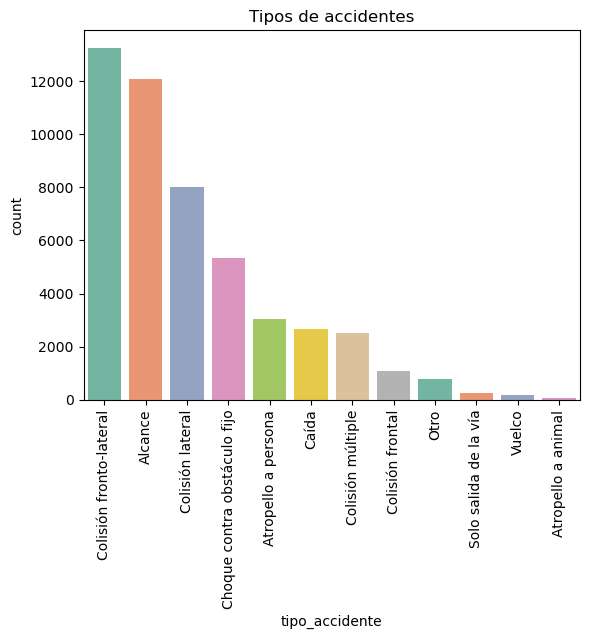

In [114]:
"""Distribución tipo de accidente"""

orden = db['tipo_accidente'].value_counts().index
sns.countplot(db, x="tipo_accidente", palette="Set2", order = orden)
plt.xticks(rotation=90) #Rota el nombre de las barras para su legibilidad.
plt.title("Tipos de accidentes")


Podemos observar como los accidentes más frecuentes son las colisiones fronto-laterales y los choques contra obstáculos fijos, siendo el atropello de animales y los vuelcos los de menor frecuencia. 

¿Qué estado meteorológico recoge más accidentes?

C:\Users\romer\AppData\Local\Temp\ipykernel_492012\211998452.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(db, x="estado_meteorológico", palette="viridis")


Text(0.5, 1.0, 'Estado meteorológico')

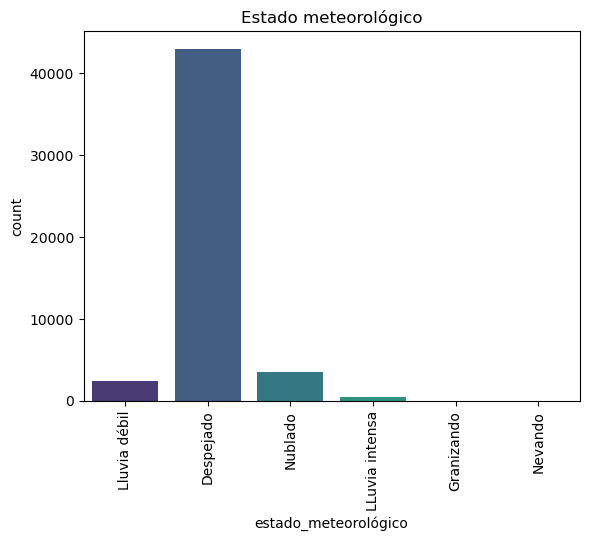

In [115]:
"""Distribución estado meteorológico"""
sns.countplot(db, x="estado_meteorológico", palette="viridis")
plt.xticks(rotation=90)
plt.title("Estado meteorológico")



Los accidentes suelen ocurrir cuando el cielo está despejado siendo casi nulos los accidentes en dias de nieve o granizo. Posiblemente porque con el cielo despejdo el conductor peca de exceso de confianza.

¿Que vehículos tienen más accidentes?

ValueError: cannot reindex on an axis with duplicate labels

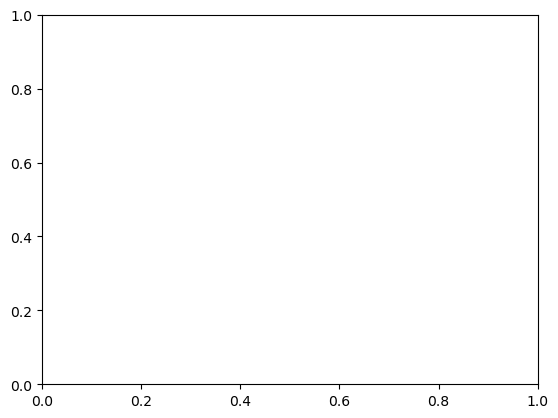

In [116]:
"""Distribución tipo de vehículo"""
orden = db["tipo_vehiculo"].value_counts().index
sns.countplot(db, x="tipo_vehiculo", palette="Set2", order = orden)
plt.xticks(rotation=90)
plt.title("Tipos de vehículos")

Y que suelen verse implicados más turismos que cualquier otro vehículo, seguido (con mucha diferencia) de motocicletas de hasta 125cc y furgonetas.

¿Qué tipo de persona tiene más accidentes?

C:\Users\romer\AppData\Local\Temp\ipykernel_310432\1934114429.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(db, x="tipo_persona", palette = "viridis")


Text(0.5, 1.0, 'Tipos de personas')

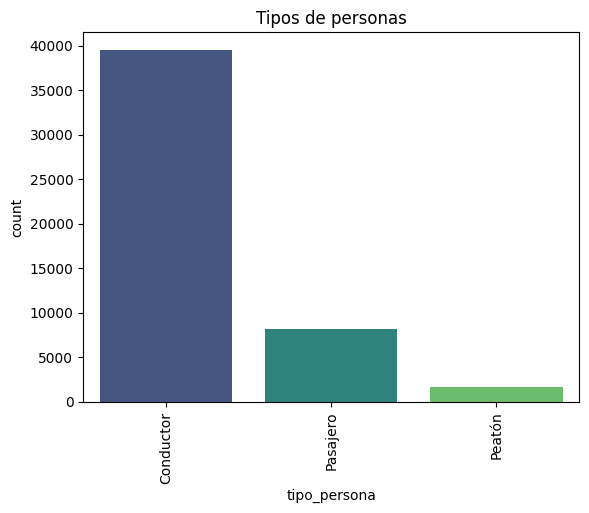

In [ ]:
"""Distribución tipo de persona"""
sns.countplot(db, x="tipo_persona", palette = "viridis")
plt.xticks(rotation=90)
plt.title("Tipos de personas")


En este gráfico podemos ver como los accidentes no suelen tener implicados peatones y tampoco suelen producirse cuando va un pasajero en el coche. 

¿Cual es el rango de edad de la mayoría de los implicados en los accidentes?

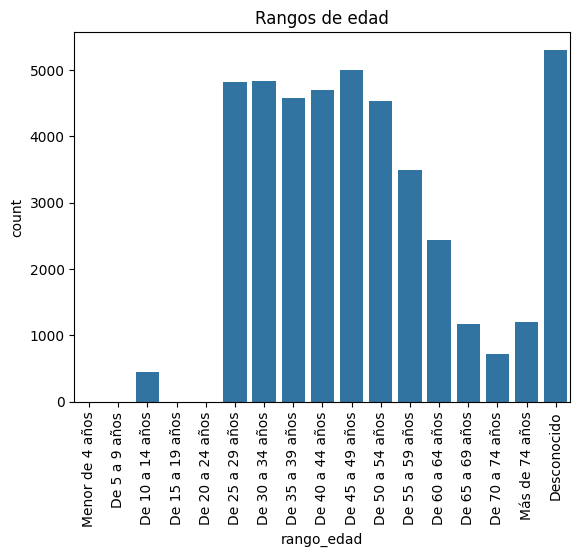

In [ ]:
"""Distribución del rango de edades"""
orden = [
    "Menor de 4 años",
    "De 5 a 9 años",
    "De 10 a 14 años",
    "De 15 a 19 años",
    "De 20 a 24 años",
    "De 25 a 29 años",
    "De 30 a 34 años",
    "De 35 a 39 años",
    "De 40 a 44 años",
    "De 45 a 49 años",
    "De 50 a 54 años",
    "De 55 a 59 años",
    "De 60 a 64 años",
    "De 65 a 69 años",
    "De 70 a 74 años",
    "Más de 74 años",
    "Desconocido"]

sns.countplot(db, x="rango_edad", order=orden)
plt.xticks(rotation=90)
plt.title("Rangos de edad")
plt.show()

En la mayoría de accidentes no se ha podido averiguar la edad de los implicados, pero podemos ver como en el rango de edad de los 25 a los 54 años os accidentes son más comunes disminuyendo poco a poco conforme se envejece.

¿Qué género tenian las personas implicadas en los accidentes?

C:\Users\romer\AppData\Local\Temp\ipykernel_310432\3602404354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(db, x="sexo", palette="Set2")


[Text(0, 0, '29805')]

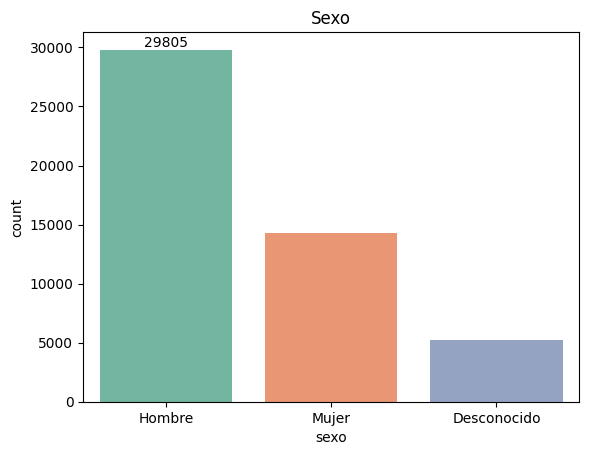

In [ ]:
"""Distribución sexo"""
ax = sns.countplot(db, x="sexo", palette="Set2")
plt.title("Sexo")

ax.bar_label(ax.containers[0])


La mayoría de accidentes es provocado por hombres con una cantidad de 29805 accidentes.

¿Que tipo de lesiones tiene la mayoría de accidentes?

Text(0.5, 1.0, 'Lesividad')

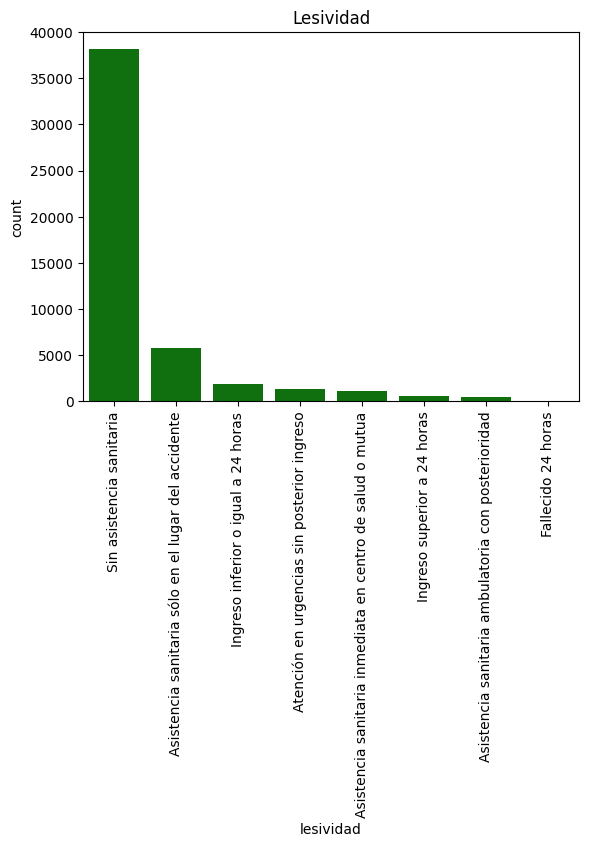

In [ ]:
"""Distribución lesividad"""
orden = db["lesividad"].value_counts().index
sns.countplot(db, x="lesividad", order = orden, color = "green")
plt.xticks(rotation=90)
plt.title("Lesividad")

Podemos observar como los accidentes no suelen tener fallecidos sino que la mayoría de accidentes no requieren de asistencia sanitaria. 

¿En que distrito ocurren más accidentes?

In [ ]:
db["distrito"].value_counts()

distrito
PUENTE DE VALLECAS     4000
CHAMARTÍN              3574
CARABANCHEL            3532
SALAMANCA              3252
CIUDAD LINEAL          3041
CENTRO                 2791
ARGANZUELA             2638
RETIRO                 2525
FUENCARRAL-EL PARDO    2508
MONCLOA-ARAVACA        2376
LATINA                 2358
TETUÁN                 2313
SAN BLAS-CANILLEJAS    2286
CHAMBERÍ               2184
USERA                  2074
HORTALEZA              1813
VILLAVERDE             1691
MORATALAZ              1437
VILLA DE VALLECAS      1222
VICÁLVARO               881
BARAJAS                 844
Name: count, dtype: int64

### 2. Distribución de las variables numéricas.

Text(0.5, 1.0, 'Control de alcoholemia')

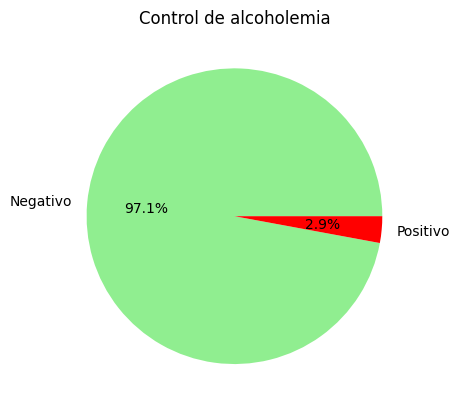

In [ ]:
"""Distribución según positivo o negativo en alcohol."""
positivos_alcohol = db["positiva_alcohol"].value_counts()
labels = ["Negativo" if x == 0 else "Positivo" for x in positivos_alcohol.index]

plt.pie(db["positiva_alcohol"].value_counts(), labels = labels, autopct="%1.1f%%", colors=["lightgreen", "red"])
plt.title("Control de alcoholemia")


Los implicados no suelen dar positivo en alcoholemia aunque 1433 personas implicadas si dieron positivo. 

Text(0.5, 1.0, 'Control de drogas')

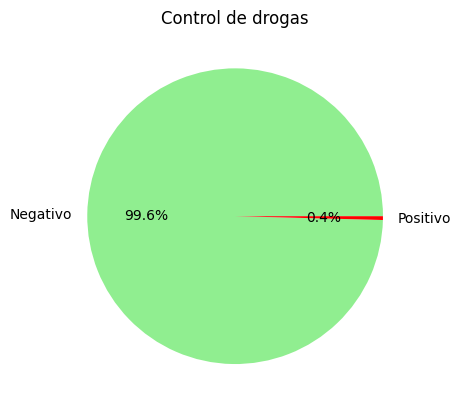

In [ ]:
"""Distribución según positivo o negativo en drogas, siendo 0: Negativo y 1: Positivo"""
positivos_droga = db["positiva_droga"].value_counts()
labels = ["Negativo" if val == 0 else "Positivo" for val in positivos_droga.index]

plt.pie(db["positiva_droga"].value_counts(), labels = labels, autopct="%1.1f%%", colors=["lightgreen", "red"])
plt.title("Control de ")


De la misma manera, casi ningún implicado dio positivo en drogas, menos que los que dieron positivo en alcohol, con una cantidad de 202.

In [ ]:
"""Primero vamos a identificar que columnas que son numéricas:"""
col_num = db.select_dtypes(include=["int64", "float64"]).columns
col_num

Index(['cod_distrito', 'cod_lesividad', 'coordenada_x_utm', 'coordenada_y_utm',
       'positiva_alcohol', 'positiva_droga', 'lesividad_codif'],
      dtype='object')

In [ ]:
"""Distribución de accidentes por distrito según el código de distrito"""
db["cod_distrito"].value_counts()

cod_distrito
13    3999
5     3574
11    3532
4     3252
15    3040
1     2785
2     2638
3     2525
8     2508
9     2373
10    2357
6     2313
20    2286
7     2184
12    2074
16    1813
17    1691
14    1437
18    1222
19     881
21     844
Name: count, dtype: int64

In [ ]:
db["cod_distrito"].value_counts(normalize=True)

cod_distrito
13    0.081070
5     0.072436
11    0.071585
4     0.065910
15    0.061634
1     0.056567
2     0.053466
3     0.051176
8     0.050831
9     0.048156
10    0.047791
6     0.046879
20    0.046332
7     0.044264
12    0.042035
16    0.036745
17    0.034272
14    0.029124
18    0.024767
19    0.017856
21    0.017106
Name: proportion, dtype: float64

In [ ]:
moda = db["cod_distrito"].mode()
db["cod_distrito"].value_counts()[moda] #repeticiones de la moda

cod_distrito
13    4000
Name: count, dtype: int64

In [ ]:
"""Distribución de la lesividad de menor a mayor"""
db["lesividad_codif"].value_counts(normalize=True) * 100

lesividad_codif
1    77.248216
2    11.731674
6     3.780814
3     2.710428
5     2.262407
7     1.149449
4     1.058223
8     0.058790
Name: proportion, dtype: float64

In [ ]:
db["lesividad_codif"].describe()

count    49328.000000
mean         1.555891
std          1.327325
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: lesividad_codif, dtype: float64

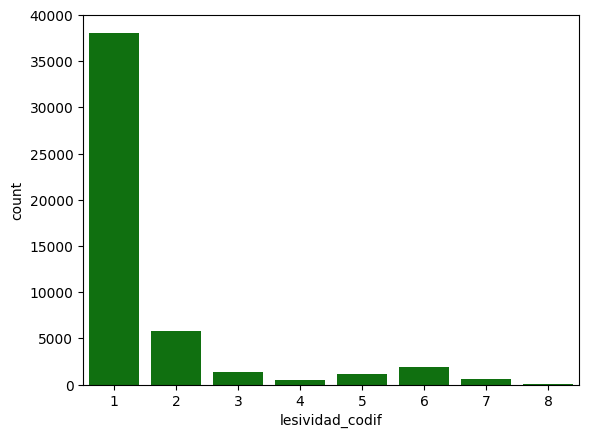

In [ ]:

sns.countplot(db, x="lesividad_codif",color = "green")
plt.show()

Si comparamos este gráfico con el que hicimos anteriormente de la lesividad podemos comprobar como los accidentes no suelen tener lesiones graves, ya que están ordenados de menor a mayor gravedad

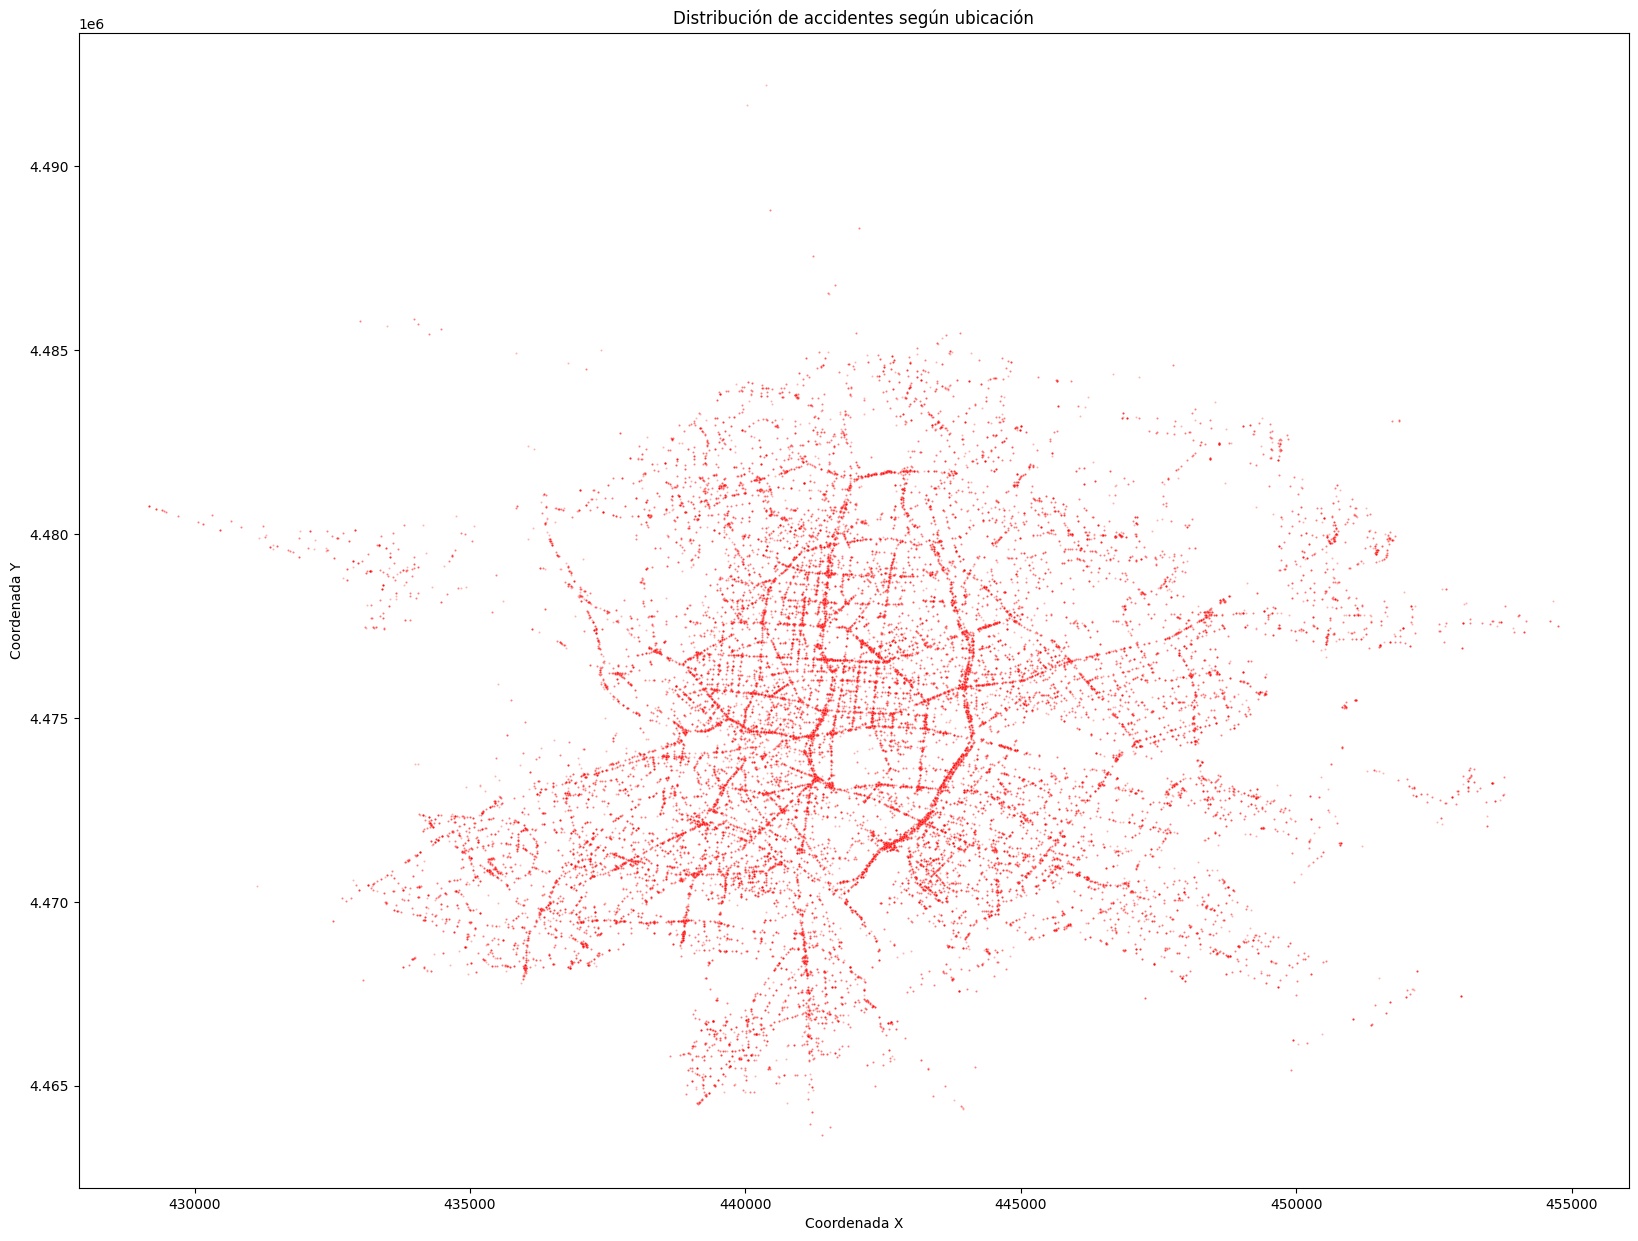

In [ ]:
"""Distribución de accidentes por sus coordenadas"""
plt.figure(figsize=(20, 15))
sns.scatterplot(db, x="coordenada_x_utm",y="coordenada_y_utm",s=2, alpha= 0.3, c="red")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.title("Distribución de accidentes según ubicación")
plt.show()


En este gráfico podemos ver un dibujo similar a un mapa de Madrid en el que podemos ver como se concentran los accientes en el centro de la ciudad y van disminuyendo hacia la periferia, siendo la M-30 y el Paseo de la Castellana las zonas más "peligrosas".

### 3. Analisis bivariante.

¿Qué tipo de accidente es el más frecuente en cada distrito?

In [ ]:
"""Primero agrupamos por distritos y luego sacamos la canitdad de tipos de accidentes, para después obtener solamente el más frecuente por grupo(idxmax()) """
accidentes_x_distrito = db.groupby("distrito")["tipo_accidente"].value_counts()

acc_x_distrito_max = accidentes_x_distrito.groupby(level=0).idxmax()

acc_x_distrito_max

distrito
ARGANZUELA                                      (ARGANZUELA, Alcance)
BARAJAS                            (BARAJAS, Colisión fronto-lateral)
CARABANCHEL                    (CARABANCHEL, Colisión fronto-lateral)
CENTRO                              (CENTRO, Colisión fronto-lateral)
CHAMARTÍN                                        (CHAMARTÍN, Alcance)
CHAMBERÍ                          (CHAMBERÍ, Colisión fronto-lateral)
CIUDAD LINEAL                                (CIUDAD LINEAL, Alcance)
FUENCARRAL-EL PARDO    (FUENCARRAL-EL PARDO, Colisión fronto-lateral)
HORTALEZA                        (HORTALEZA, Colisión fronto-lateral)
LATINA                              (LATINA, Colisión fronto-lateral)
MONCLOA-ARAVACA                            (MONCLOA-ARAVACA, Alcance)
MORATALAZ                                        (MORATALAZ, Alcance)
PUENTE DE VALLECAS      (PUENTE DE VALLECAS, Colisión fronto-lateral)
RETIRO                                              (RETIRO, Alcance)
SALAMANCA  

In [ ]:
acc_y_distrito_max = accidentes_x_distrito.idxmax()
acc_y_distrito_max

('PUENTE DE VALLECAS', 'Colisión fronto-lateral')

Podemos ver que el lugar en el que hay más accidentes es el Puente de Vallecas, en el que se producen con más frecuencia colisiones fronto-laterales.

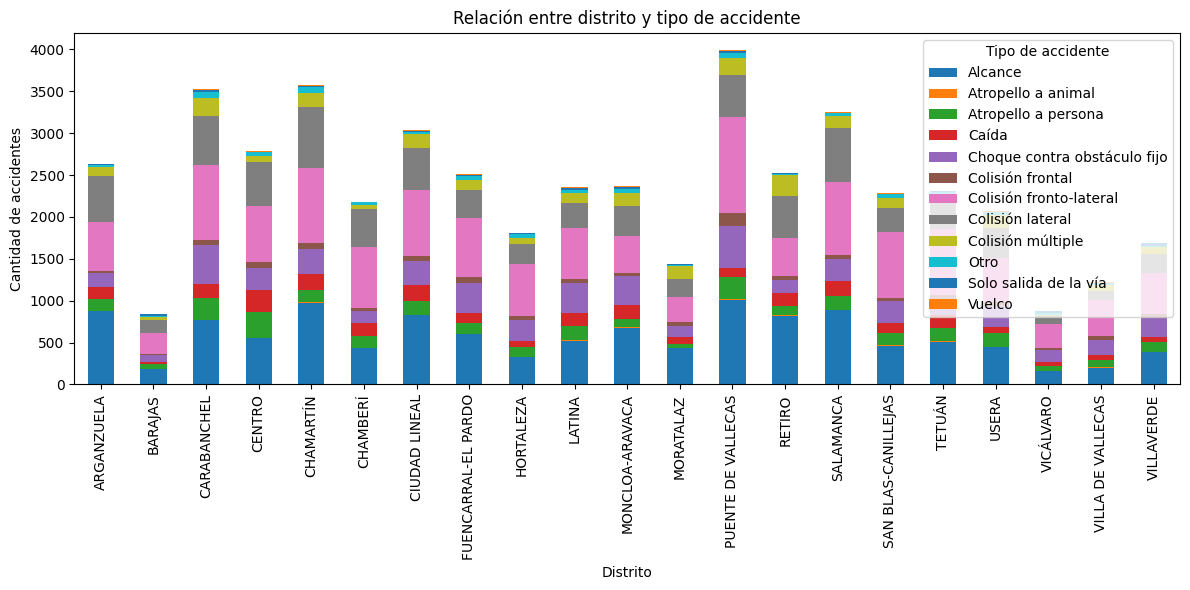

In [ ]:
tabla = db.groupby(["distrito", "tipo_accidente"]).size().unstack()
tabla.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Relación entre distrito y tipo de accidente")
plt.xlabel("Distrito")
plt.ylabel("Cantidad de accidentes")
plt.legend(title="Tipo de accidente")
plt.tight_layout()


¿Qué franja horaria concentra mayor número de atropellos a personas?

In [118]:
"""Para reponder esta pregunta primero debemos crear una variable que recoja solamente las filas que contengan como tipo de accidente "Atropello a persona". """
atropellos = db[db["tipo_accidente"] == "Atropello a persona"]

"""Creamos una función que nos separe las horas por franja horaria y creamos una columna con los valores resultado par las frnajas y otra para los atropellos por franja."""

def franja(x):
    if 6 <= x < 13:
        return "Mañana (6-13)"
    elif 13 <= x < 22:
        return "Tarde (13-22)"
    else:
        return "Noche (22-6)"
    
db["franja_horaria"] = db["hora"].apply(franja)
    
atropellos["franja_atropellos"] = atropellos["hora"].apply(franja)

atropellos["franja_atropellos"].value_counts()

C:\Users\romer\AppData\Local\Temp\ipykernel_492012\2730853184.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atropellos["franja_atropellos"] = atropellos["hora"].apply(franja)


franja_atropellos
Tarde (13-22)    1671
Mañana (6-13)    1061
Noche (22-6)      310
Name: count, dtype: int64

En conclusión, por las mañanas hay un total de 1061 accidentes, por las tardes 1671 y por la snoches es la franja horaria en la que menos accidenteshan habido con un total de 310.

In [ ]:
db.hora.value_counts()

hora
19    3533
18    3456
14    3357
15    3288
17    3150
20    3063
13    2932
16    2730
12    2573
9     2567
21    2273
8     2159
11    2156
10    1962
22    1776
23    1446
7     1344
0     1230
1     1055
6      924
2      713
5      634
3      549
4      458
Name: count, dtype: int64

Y podemos concretar más. Puntualizamos que las horas de más accidentealidad son entre las 18h y las 19h.

¿Que franja horaria tiene más accidentes graves?

C:\Users\romer\AppData\Local\Temp\ipykernel_132908\320568575.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tabla.index, y=tabla.values, palette="Reds_r")


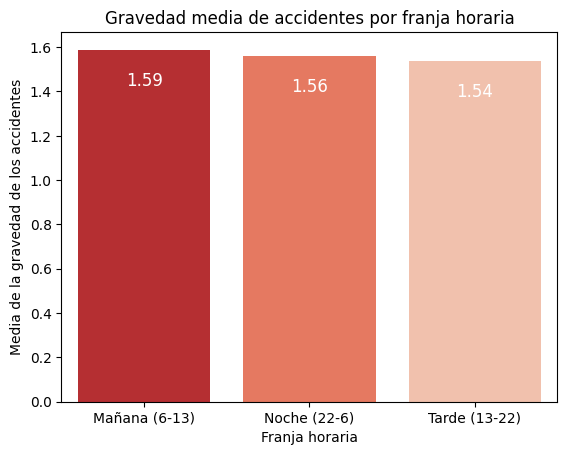

In [ ]:
tabla = db.groupby("franja_horaria")["lesividad_codif"].mean().sort_values(ascending=False)

ax = sns.barplot(x=tabla.index, y=tabla.values, palette="Reds_r")
plt.title("Gravedad media de accidentes por franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Media de la gravedad de los accidentes")


for i, valor in enumerate(tabla.values):
    ax.text(i, valor - 0.1, f"{valor:.2f}", color="white", ha='center', va='top', fontsize=12)


En este gráfico podemos ver como durante las mañanas suceden los accidentes más graves.

¿Se observa que los accidentes que ocurren por la noche tienen mayor incidencia de positividad en alcohol?

In [ ]:
db["franja_horaria"] = db["hora"].apply(franja)
tabla_porcentajes = db.groupby("franja_horaria")["positiva_alcohol"].mean()*100
tabla_porcentajes

franja_horaria
Mañana (6-13)    1.797589
Noche (22-6)     8.497647
Tarde (13-22)    1.868116
Name: positiva_alcohol, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

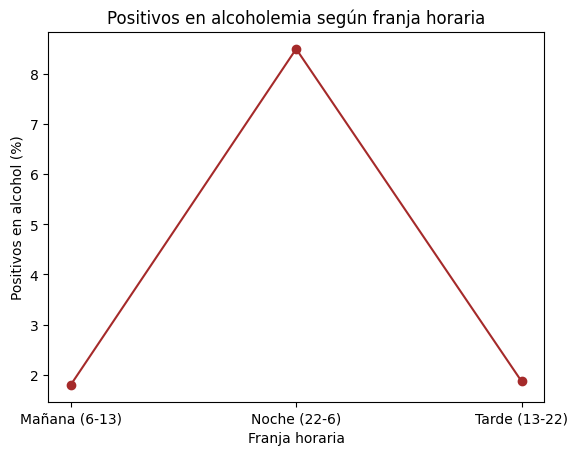

In [ ]:
plt.plot(tabla_porcentajes, marker='o', linestyle='-', color = "brown")
plt.ylabel("Positivos en alcohol (%)")
plt.xlabel("Franja horaria")
plt.title("Positivos en alcoholemia según franja horaria")
plt.show

Claramente podemos obervar que por la noche hay muchos más accidentes con positivo en alcoholemia que el resto del día.

¿Y los accidentes graves suelen coincidir con positivos en alcohol?

C:\Users\romer\AppData\Local\Temp\ipykernel_132908\2476419093.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tabla2.index, y=tabla2.values, palette="Reds_r")


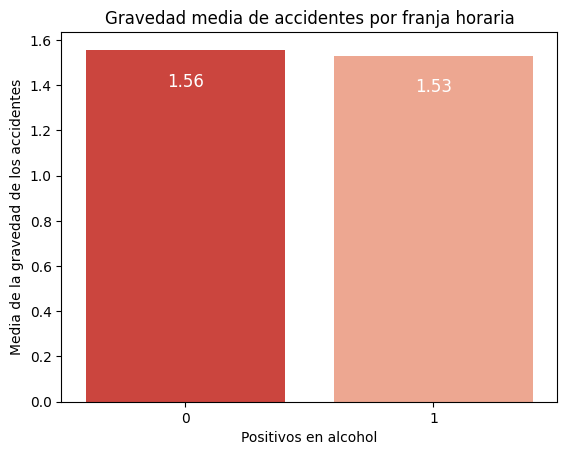

In [ ]:
tabla2 = db.groupby("positiva_alcohol")["lesividad_codif"].mean().sort_values(ascending=False)

ax = sns.barplot(x=tabla2.index, y=tabla2.values, palette="Reds_r")
plt.title("Gravedad de los accidentes en positivos y negativos de alcoholemia.")
plt.xlabel("Positivos en alcohol")
plt.ylabel("Media de la gravedad de los accidentes")


for i, valor in enumerate(tabla2.values):
    ax.text(i, valor - 0.1, f"{valor:.2f}", color="white", ha='center', va='top', fontsize=12)

Observamos que hay muy poca diferencia entre los positivos y los negativos en alcohol en accidentes graves, por lloo que pensamos que no es un factor demasiado relevante. 

¿Y que hay de los positivos en drogas?

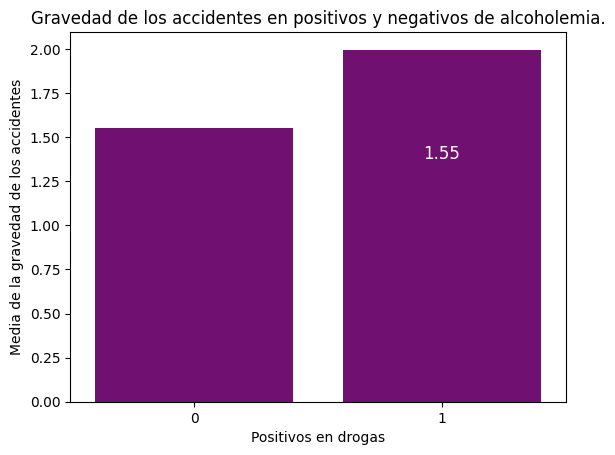

In [ ]:
tabla3 = db.groupby("positiva_droga")["lesividad_codif"].mean().sort_values(ascending=False)

ax = sns.barplot(x=tabla3.index, y=tabla3.values, color="Purple")
plt.title("Gravedad de los accidentes en positivos y negativos de alcoholemia.")
plt.xlabel("Positivos en drogas")
plt.ylabel("Media de la gravedad de los accidentes")


for i, valor in enumerate(tabla3.values):
    ax.text(i, valor - 0.1, f"{valor:.2f}", color="white", ha='center', va='top', fontsize=12)

En cambio si vemos una diferencia significativa en los positivos en drogas, siendo estos más comunes en los accidentes graves. 

¿En qué tipos de accidente se da más frecuencia de positivos en alcohol?

In [ ]:
"""Para saber esto primero vamos a callcular la media de positivos en cada tipo de accidente"""
positivos_alcohol2= db[db["positiva_alcohol"] == 1]
tabla_positivos_por_accidente = positivos_alcohol2["tipo_accidente"].value_counts()
tabla_positivos_por_accidente



tipo_accidente
Choque contra obstáculo fijo    455
Alcance                         253
Colisión fronto-lateral         245
Colisión lateral                151
Caída                           114
Colisión múltiple                57
Atropello a persona              49
Colisión frontal                 39
Solo salida de la vía            37
Vuelco                           23
Otro                             10
Name: count, dtype: int64

C:\Users\romer\AppData\Local\Temp\ipykernel_132908\1223885822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(tabla_positivos_por_accidente, palette="Set2")


Text(0.5, 1.0, 'Positivos en alcohol según el tipo de accidente')

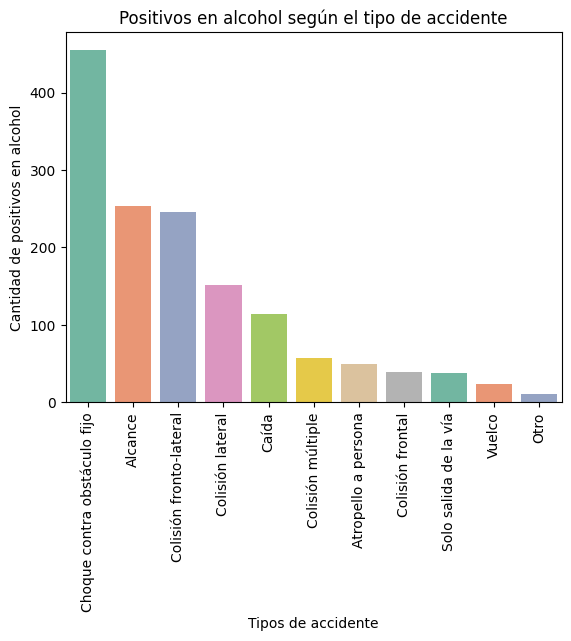

In [ ]:
"""Ahora creamos un gráfico para visualizar la tabla creada:"""

sns.barplot(tabla_positivos_por_accidente, palette="Set2")
plt.ylabel("Cantidad de positivos en alcohol")
plt.xlabel("Tipos de accidente")
plt.xticks(rotation=90)
plt.title("Positivos en alcohol según el tipo de accidente")

En la tabla y el gráfico podemos ver como los positivos en alcoholemia se concentran en choques contra obstáculos fijos y después en alcances y colisiones fronto-laterales.

¿Hay relación entre el tipo de persona (conductor, peatón, testigo, etc.) y el tipo de accidente?


In [ ]:
tabla =pd.crosstab(db["tipo_persona"], db["tipo_accidente"])

tabla


tipo_accidente,Alcance,Atropello a animal,Atropello a persona,Caída,Choque contra obstáculo fijo,Colisión frontal,Colisión fronto-lateral,Colisión lateral,Colisión múltiple,Otro,Solo salida de la vía,Vuelco
tipo_persona,,,,,,,,,,,,
Conductor,9615,66,1402,2315,4757,911,10550,6848,2079,669,197,144
Pasajero,2453,3,217,308,531,177,2660,1152,453,110,51,38
Peatón,22,8,1423,51,45,6,35,17,0,14,1,0


En la tabla cruzada podemos observar como en los accidentes con conductores predominan las colisiones fronto-laterales(10550) y los alcances (9617). En accidentes con pasajeros tenemos el mismo resultado (colision fronto-lateral: 2660 y alcances: 2453). En el caso de los peatones las accidentes más comunes, como era de esperar, son los atropellos a personas con un total de 1423.

Text(0.5, 1.0, 'Accidentes por tipo de persona')

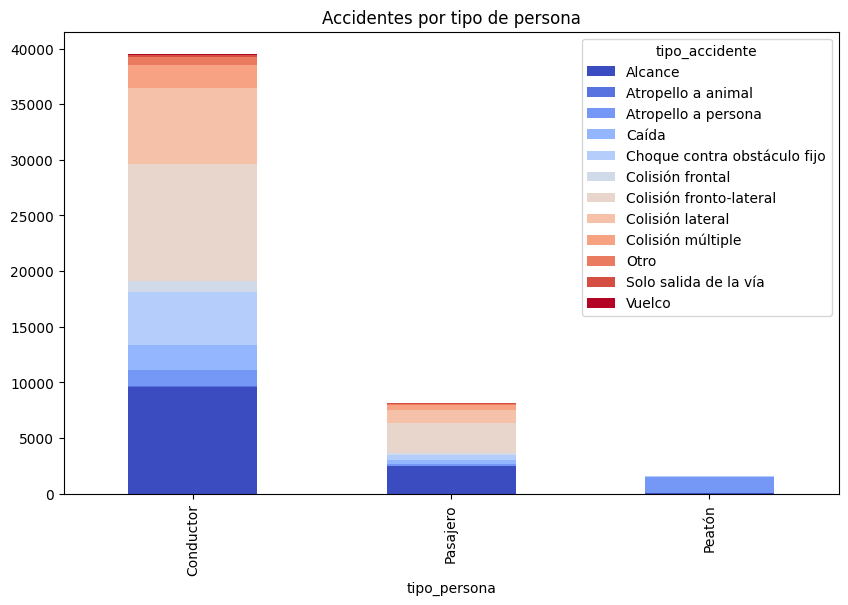

In [ ]:
"""Para visualizarlo mejor vamos a ponerlo en un grafico de barras apiladas"""
tabla.plot(kind = "bar", stacked=True, figsize=(10,6), colormap="coolwarm")
plt.title("Accidentes por tipo de persona")

In [ ]:
tabla =pd.crosstab(db["tipo_persona"], db["lesividad_codif"])

tabla


lesividad_codif,1,2,3,4,5,6,7,8
tipo_persona,,,,,,,,
Conductor,31796,4044,900,358,798,1298,349,10
Pasajero,5953,1313,244,103,182,299,57,2
Peatón,356,430,193,61,136,268,161,17


De la misa manera, creamos una tabla para saber la relación entre la gravedad de los accidentes y el tipo de persona implicada para saber si el tio de persona es un factor que influye en esta gravedad o no y concluimos que los datos son bastante parejos y, por lo tanto, no es un factor que influya enromemente.  

¿Qué dias de la semana hay más positivos en alcohol?

In [ ]:
"""Creamos una tabla con las variables relacionadas y sus porcentajes"""
tabla_dias_positivos = pd.crosstab(
    db["dia_semana"],
    db["positiva_alcohol"],
    normalize="index"
) * 100
tabla_dias_positivos

positiva_alcohol,0,1
dia_semana,,
Friday,97.184657,2.815343
Monday,98.241665,1.758335
Saturday,94.883998,5.116002
Sunday,94.263622,5.736378
Thursday,97.805896,2.194104
Tuesday,98.118168,1.881832
Wednesday,98.362262,1.637738


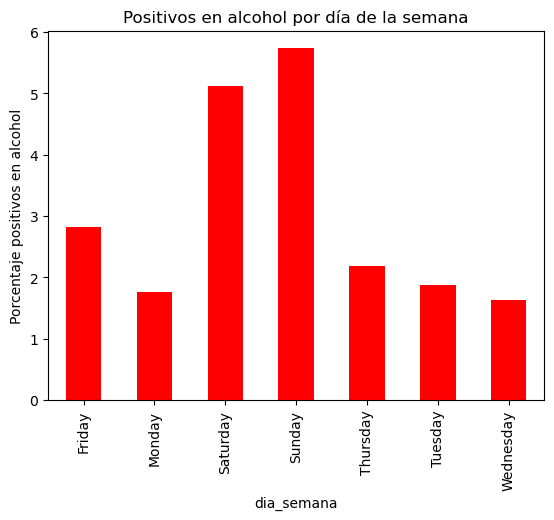

In [ ]:
"""Creamos una gráfica para poder verlo  de manera más intuitiva"""
tabla_dias_positivos[1].plot(kind="bar", color = "red")
plt.ylabel("Porcentaje positivos en alcohol")
plt.title("Positivos en alcohol por día de la semana")
plt.show()

La gráfica nos muestra que la cantidad de positivos en alcoholemia es considerablemente más elevada los fines de semana que entre semana, ahora deberíamos preguntarnos si también hay más accidentes los fines de semana para concluir si la alcoholemia es un factor que influye en la posibilidad de tener accidentes. 

¿Que días de la semana son más conflictivos, hay más accidentes el fin de semana o entre semana?

In [ ]:
db["dia_semana"].value_counts()

dia_semana
Friday       8134
Thursday     7429
Tuesday      7227
Wednesday    7144
Monday       7109
Saturday     6724
Sunday       5561
Name: count, dtype: int64

C:\Users\romer\AppData\Local\Temp\ipykernel_132908\1648936975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(db, x="dia_semana",  palette="pastel", order = orden)


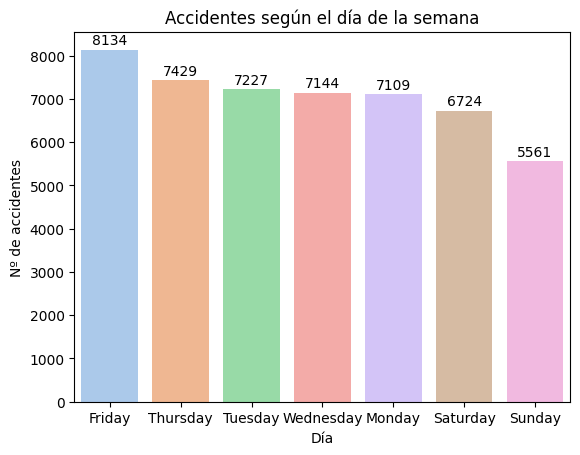

In [ ]:
orden = db["dia_semana"].value_counts().index
ax = sns.countplot(db, x="dia_semana",  palette="pastel", order = orden)
plt.title("Accidentes según el día de la semana")
plt.xlabel("Día")
plt.ylabel("Nº de accidentes")

for x in ax.patches:
    altura_barra = x.get_height()
    ax.text(x.get_x() + x.get_width()/2, altura_barra + 50, int(altura_barra), ha="center", va="bottom")

Observamos como no hay mucha variación en la cantidad de accidentes entre día de la semana, aunque podríamos matizar que el fin de semana ocurren menos accidentes que en el resto de la semana y que el viernes es el día más conflictivo con un total de 8136 accidentes. 

¿En qué meses del año (o estaciones) se produce un mayor número de accidentes?

In [ ]:
"""Pimero de todo creamos una columna que recoja solamente los meses de los accidentes por su nombre en lugar de por su número."""
db["meses"] = db["fecha"].dt.month_name()

meses = db["meses"].value_counts()


C:\Users\romer\AppData\Local\Temp\ipykernel_132908\2207727808.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(meses, palette=colores)


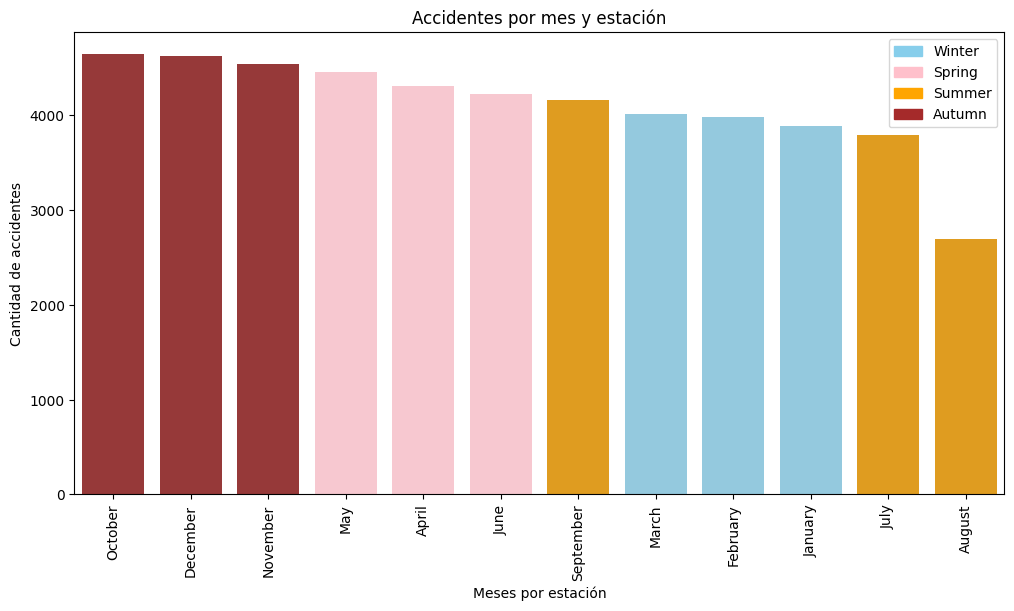

In [ ]:
"""Y lo visualizamos en un gráfico que muestre de mayor a menor los accidentes por mes e indique las estaciones por colores"""
estaciones={"January": "Winter","February": "Winter","March": "Winter",  "April": "Spring", "May":"Spring", "June":"Spring", "July":"Summer", "August":"Summer", "September":"Summer", "October": "Autumn", "November": "Autumn", "December":"Autumn"}

colores_por_estacion ={"Winter": "skyblue","Spring": "pink","Summer":"orange","Autumn":"brown"}

colores = [colores_por_estacion[estaciones[mes]] for mes in meses.index]

plt.figure(figsize=(12, 6))
sns.barplot(meses, palette=colores)
plt.xticks(rotation=90)
plt.xlabel("Meses por estación")
plt.ylabel("Cantidad de accidentes")
plt.title("Accidentes por mes y estación")


"""Y para que se entienda mejor le añadimos manualmente una leyenda:"""
from matplotlib.patches import Patch

leyenda = [Patch(color="skyblue", label="Winter"),Patch(color="pink", label="Spring"),Patch(color="orange", label="Summer"),Patch(color="brown", label="Autumn")]

plt.legend(handles=leyenda)


Podemos ver como en otoño (Octubre, Noviembre  y Diciembre) hay más accidentes que en el resto del año, seguido por primavera (Abril, Mayo y Junio).


¿Se observa alguna relación entre el estado meteorológico y la lesividad de los accidentes?

C:\Users\romer\AppData\Local\Temp\ipykernel_132908\1132736862.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=medias.index, y=medias.values, palette= "viridis")


Text(0.5, 1.0, 'Gravedad de lesiones según clima')

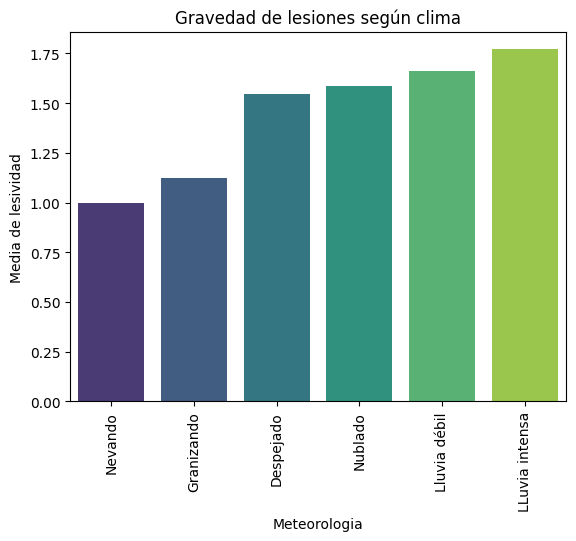

In [ ]:
"""Para ello tenemos que crear un nuevo DataFrame en el que recojemos la columna de estado meteorológico sin la variable "Se desconoce" para que no de errores. """
df_clima = db[db["estado_meteorológico"] != "Se desconoce"]

"""Después calculamos las medias de la lesividad y las ordenamos de menor a mayor gravedad, para, con ellas, obtener una idea de la información que buscamos."""
medias = df_clima.groupby("estado_meteorológico")["lesividad_codif"].mean().sort_values()

"""Visualizamos la relación entre las medias de lesividad y el clima:"""
sns.barplot(x=medias.index, y=medias.values, palette= "viridis")
plt.xticks(rotation=90)
plt.ylabel("Media de lesividad")
plt.xlabel("Meteorologia")
plt.title("Gravedad de lesiones según clima")


En el gráfico de barras observamos como la gravedad de los accidentes que ocurren con lluvia (intensa y débil) es mayor que con el resto de estados meteorológicos y que la nieve y el granizo se asocian con lesiones más leves.

## 3. Análisis geográfico

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
"""Primero relacionamos cada coordenada x con la coordenada y con un zip y creamos un objeto punto para cada una de las tuplas x,y."""
punto_coordenadas = [Point(x) for x in zip(db["coordenada_x_utm"], db["coordenada_y_utm"])]
punto_coordenadas


[<POINT (444913 4481427)>,
 <POINT (444913 4481427)>,
 <POINT (440123 4475170)>,
 <POINT (440123 4475170)>,
 <POINT (440137 4475721)>,
 <POINT (440137 4475721)>,
 <POINT (440709 4480102)>,
 <POINT (440709 4480102)>,
 <POINT (433983 4468473)>,
 <POINT (433983 4468473)>,
 <POINT (437064 4478229)>,
 <POINT (443927 4473998)>,
 <POINT (443927 4473998)>,
 <POINT (443927 4473998)>,
 <POINT (443927 4473998)>,
 <POINT (443927 4473998)>,
 <POINT (443927 4473998)>,
 <POINT (443927 4473998)>,
 <POINT (443927 4473998)>,
 <POINT (443927 4473998)>,
 <POINT (443249 4471571)>,
 <POINT (443249 4471571)>,
 <POINT (443249 4471571)>,
 <POINT (443249 4471571)>,
 <POINT (443249 4471571)>,
 <POINT (444513 4473729)>,
 <POINT (444513 4473729)>,
 <POINT (436809 4469484)>,
 <POINT (436809 4469484)>,
 <POINT (436809 4469484)>,
 <POINT (440193 4474773)>,
 <POINT (440193 4474773)>,
 <POINT (437002 4470046)>,
 <POINT (437002 4470046)>,
 <POINT (442700 4475970)>,
 <POINT (442700 4475970)>,
 <POINT (441549 4475931)>,
 

In [ ]:
"""Luego convertimos esto en un geodataframe"""
geo_data_frame = gpd.GeoDataFrame(db, geometry=punto_coordenadas)
geo_data_frame.set_crs(epsg=25830, inplace=True) #Con esto le indicamos el Sistema de referencia espacial de Madrid (UTM).
geo_data_frame

,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,lesividad_codif,geometry
num_expediente,,,,,,,,,,,,,,,,,,,,
2023S040280,2024-01-04,14,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,Conductor,De 55 a 59 años,Hombre,2.0,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,0,0,6,POINT (444913 4481427)
2023S040280,2024-01-04,14,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,Conductor,De 55 a 59 años,Mujer,14.0,Sin asistencia sanitaria,444913.0,4481427.0,0,0,1,POINT (444913 4481427)
2023S040309,2024-02-15,14,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,Conductor,De 25 a 29 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del acci...,440123.0,4475170.0,0,0,2,POINT (440123 4475170)
2023S040309,2024-02-15,14,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Motocicleta hasta 125cc,Conductor,De 35 a 39 años,Hombre,14.0,Sin asistencia sanitaria,440123.0,4475170.0,0,0,1,POINT (440123 4475170)
2023S040310,2024-02-18,10,GTA. RUIZ JIMENEZ / CALL. SAN BERNARDO,3,7,CHAMBERÍ,Colisión lateral,Despejado,Turismo,Conductor,De 25 a 29 años,Hombre,14.0,Sin asistencia sanitaria,440137.0,4475721.0,0,0,1,POINT (440137 4475721)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024S035474,2024-12-23,11,CALL. LUCANO / CALL. CANAL DEL BOSFORO,1,20,SAN BLAS-CANILLEJAS,Otro,Despejado,Camión rígido,Conductor,De 25 a 29 años,Hombre,14.0,Sin asistencia sanitaria,448109.0,4476801.0,0,0,1,POINT (448109 4476801)
2024S035479,2024-12-03,9,GTA. SAN VICENTE / AVDA. PORTUGAL,1,9,MONCLOA-ARAVACA,Otro,Despejado,Autobús,Conductor,De 40 a 44 años,Hombre,14.0,Sin asistencia sanitaria,438883.0,4474597.0,0,0,1,POINT (438883 4474597)
2024S035479,2024-12-03,9,GTA. SAN VICENTE / AVDA. PORTUGAL,1,9,MONCLOA-ARAVACA,Otro,Despejado,Turismo,Conductor,De 50 a 54 años,Hombre,14.0,Sin asistencia sanitaria,438883.0,4474597.0,0,0,1,POINT (438883 4474597)


Text(0.5, 1.0, 'Mapa de densidad de accidentes')

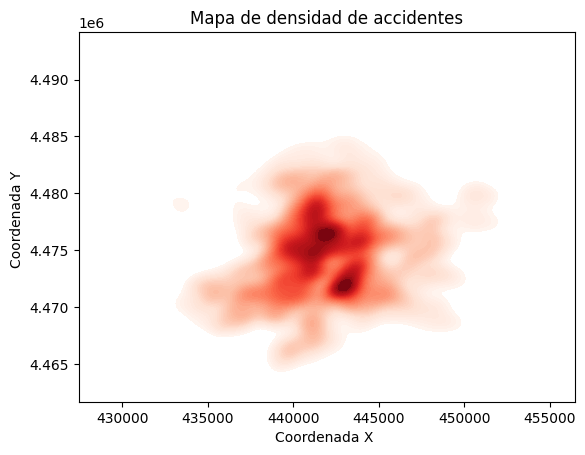

In [ ]:
"""Creamos un mapa de densidad de los accidentes:"""
sns.kdeplot(x=geo_data_frame.geometry.x, y=geo_data_frame.geometry.y, cmap="Reds", fill=True,levels=50)
plt.xlabel("Coordenada X ")
plt.ylabel("Coordenada Y ")
plt.title("Mapa de densidad de accidentes")

En este mapa de densidad podemos observar como los accidentes se concentran en el centro, posiblemente se trate del centro urbano, tal y como vimos en el mapa anterior y podemos ubicar 2 puntos calientes en los cuales ha habido más accidentes a lo largo del año, independientemente de su gravedad, y hacia las periferias los accidentes disminuyen, seguramente por que hay menos flujo de tráfico en dichas zonas.

Text(0, 0.5, 'Coordenada Y')

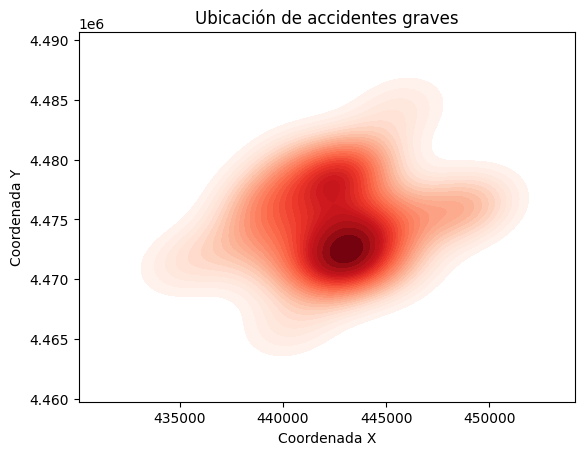

In [ ]:
"""Para obtener los puntos calientes de los accidentes graves debemos primero seleccionar los accidentes graves y despupés hacer el mapa densidad."""
graves = geo_data_frame[geo_data_frame["lesividad_codif"] >= 8] 
coordenadas_graves = graves[["coordenada_x_utm", "coordenada_y_utm"]]


sns.kdeplot(coordenadas_graves,x="coordenada_x_utm",y="coordenada_y_utm", cmap="Reds", fill=True,levels=30)
plt.title("Ubicación de accidentes graves")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

Si comparamos este mapa de densidad con el anterior vemos que solamente tiene un punto caliente y se encuentra en la misma ubicación que uno de los puntos calientes de accidentes del mapa anterior. Esto quiere decir que en uno de los puntos con más accidentes de la ciudad corresponde con el punto en el que ocurren los accidentes más graves o lesivos. 

# 4. Conclusiones finales.

Tras analizar en profundidad los datos de accidentalidad de Madrid en 2024, extraemos las siguientes conclusiones:

<u>1. Cantidad de accidentes.</u>
- En total hubieron 49340 accidentes repartidos a lo largo del año 2024, de los cuales hemos podido aprovechar 49328 (el resto se descartató por falta de datos).
- Los accidentes se concentran, sobre todo, en los días laborables, manteniendose mas o menos estables en cantidad, pero se destaca que el viernes es el día con más accidentalidad y suponemos que la causa es la operación salida para el fin de semana. 
- La mayor cantidad de accidentes suceden en horario de tarde (entre las 18h y 19h), seguido de las mañanas (entradas y salidas del trabajo), siendo por las noches cuando menos accidentes hay.
- Y se observa que los días despejados son aquellos en los que hay más accidentes con diferencia, contando con un total de 42998 accidentes, es decir, la gran mayoría de estos ocurren en días soleados (suponemos que es debido a un exceso de confianza de los conductores).

<u>2. Características de los accidentes.</u>
- <n>Tipos de accidentes.</n> La mayoría de accidentes se corresponden con colisiones fronto-laterales, alcances y colisiones laterales. 
- <n>Tipo de vehículo.</n>
- <n>Perfil de los implicados. </n>

<u>3. Zonas de peligro.</u>
- Tras realizar los mapas de densidad anteriores extraemos la conclusión de que existen dos puntos calientes de accidentes en la ciudad, concretamente en la Avenida de la Castellana y en la M-30 y la Avenida de la Paz. Suponemos que son calles de gran afluencia y tráfico, por lo que los accidentes son más comunes en estas zonas. Destacamos que la M-30 suele ser carretera de salida los fines de semana, lo que respalda nuestra conclusión anterior. 
- Observamos también que en el centro de la ciudad ocurren más accidente y van disminuyendo conforme nos acercamos a la periferia. Entemos que por el mismo motivo, mayor afluencia de personas, mayor tráfico. 

<u>4. Factores de riesgo.</u>
- <n>Alcoholemia.</n> No pensamos que la positividad en alcoholemia sea un factor de riesgo relevante ya que en la totalidad de los accidentes hay una cantidad poco significante de positivos en alcohol, por lo que no es la causa directa de los accidentes. Tampoco encontramos relación entre la gravedad de los accidentes y el positivo en alcoholemia. 
- <n>Drogas.</n> En cambio si destacamos una relación importante a tener en cuenta entre los positivos en dorgas y los accidentes graves, suponiendo así que las positividad den drogas es un factor de reisgo en la gravedad de los accidentes. 
- <n>Ubicación.</n> SEgún la localización hay más probabilidades o menos de sufrir un accidente, siendo el centro de la ciudad la zona de mayor probabilidad, focalizado en la M-30 y la Castellana, correspondiendo con los distritos del Puente de Vallecas, Chamartín y Carabanchel (en dicho orden).  
- <n>Vehículo.</n> Respecto al tio de vehículo podemos observar como los turismos son los protagonistas de la mayoría de accidentes, entendemos que es debido a que la cantidad de turismos es mayor que el resto de vehículos pero no podemos afirmarlo con seguridad pues se trata de una conjetura sin ningún información oficial que lo avale.
- <n>Condiciones meteorológicas.</n> Llegamos a la conclusión de que se debe extremar la precaución al volante los días de lluvia intensa y debil, ya que son las condiciones meteorológicas en las que se producen accidentes con mayor gravedad. Aun y así, debemos tener en cuenta que los días en los que ocurren más accidentes (aunque estps no sean de alta gravedad) son los días despejados (suponemos que es por exceso de confianza de los conductores).

<u>¿En qué franja horaria se producen los accidentes con mayor gravedad (ingreso superior a 24 horas o fallecidos) y qué condiciones (estado meteorológico, tipo de accidente, etc.) pueden influir en ello?”</u>

Los accidentes con mayor gravedad (ingresos hospitalarios superiores a 24 horas o fallecidos) se concentran principalmente por las mañanas y, la lluvia (ya sea intensa o debil) es una condición que puede influir en la gravedad de las lesiones en los accidentes de tráfico.



# MODELO DE REGRESIÓN LOGÍSTICA

## Fase 1. Seleción y preparación de variables.

- Variable objetivo: positiva_alcohol
- Variables predictoras: tipo_dia, distrito, franja_horaria, sexo, rango_edad

In [ ]:
"""
Objetivo: Predecir la probabilidad de que una persona implicada en un accidente diera positivo en alcohol, utilizando información demográfica y contextual del accidente.
Codificamos las variables categóricas usando one-hot encoding"""
variables_predictoras = ["tipo_dia", "franja_horaria", "distrito", "sexo", "rango_edad"]
x = db[variables_predictoras]
y = db["positiva_alcohol"]

x = pd.get_dummies(x, drop_first=True)


"""Y lo escalamos para mejorar el modelo y evitar errores de aprendizaje"""

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

## Fase 2. Separación de datos.

In [121]:
"""Separamos los datos con el train_test_split() para que el test y el train se ejecuten con datos distintos"""
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2, #reservamos el 20% de los datos para hacer el test después.
    random_state=12, #usamos un valor fijo para hacerlo reproducible.
    stratify=y #Así nos aseguramos que los positivos en alcohol están repartidos en la muestra del train y en la del test. 
)

"""Es importante que escalemos los datos de nuevo."""
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)



## Fase 4. Testing de la clase. 

In [ ]:
"""Primero creamos unos datos random para utilizar y ver si la clase que hemos creado en el archivo.py funciona bien."""
import numpy as np

x_inventado = np.array([
    [0.2, -1.3, 0.5],
    [1.1,  0.3, -0.7],
    [-0.5, 0.8, 1.2],
    [1.5, -0.2, -1.0],
    [-1.2, 1.4, 0.3],
    [0.7, -0.9, 1.1]
])

y_inventado = np.array([0, 1, 0, 1, 0, 1])

"""Después hacemos un split simple."""
x_train, x_test, y_train, y_test = train_test_split(
    x_inventado,
    y_inventado,
    test_size=0.3,
    random_state=1,
    stratify=y_inventado 
)

"""Ahora ya podemos probar la clase con el conjunto de datos que acabamos de crear:"""
from alcohol_logistic_model import AlcoholLogisticModel

modelo_prueba = AlcoholLogisticModel(random_state=1)
modelo_prueba.fit(x_train, y_train)


In [ ]:
"""Realizamos las predicciones:"""
predicciones = modelo_prueba.predict(x_test)
predicciones

array([0, 1])

In [ ]:
"""Realizamos las métricas:"""
metricas = modelo_prueba.evaluate(x_test, y_test)
metricas

{'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'confusion_matrix': array([[1, 0],
        [0, 1]], dtype=int64)}

In [ ]:
"""Guardamos el modelo y lo cargamos:"""
modelo_prueba.save_model("test_model.pkl")
new_model = AlcoholLogisticModel()

new_model.load_model("test_model.pkl")
new_model.predict(x_test)


array([0, 1])

Ahora que nos hemos asegurado de que nuestra clase y todos sus métodos funcionan correctamente utilizando datos inventados fuera de nuestro conjunto de datos real, pasamos a entrenar nuestro modelo con los datos de los accidentes. 

## Fase 5. Entrenamiento del modelo.

In [ ]:
"""Importamos el modelo par apoder usarlo y creamos una instancia."""
from alcohol_logistic_model import AlcoholLogisticModel
modelo = AlcoholLogisticModel(
    random_state=12,
    max_iter=1000
)

"""Entrenamos el dmodelo, aquí no está evlauando nada, solamente se entrena, aprende patrones entre las variables."""
modelo.fit(x_train_scaled, y_train)
metricas


{'accuracy': 0.9709101966349077,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'confusion_matrix': array([[9579,    0],
        [ 287,    0]], dtype=int64)}

In [ ]:
"""Evaluamos el entrenamiento:"""

metricas = modelo.evaluate(x_test_scaled, y_test)
"""Es importante que nos fijemos en f1 y en recall, pues el accuracy, como comenté anrteriormente, no aplica demasiado ahora mismo."""
metricas 


c:\Users\romer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'accuracy': 0.9709101966349077,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'confusion_matrix': array([[9579,    0],
        [ 287,    0]], dtype=int64)}

## Fase 6. Evaluación e interpretación de los resultados.

In [ ]:
"""Ya podemos extraer las métricas y lo ponemos de manera que solo nos muestre los dos primeros decimales para tener un resultado más limpio:"""
print(f"Accuracy: {metricas['accuracy']:.2f}")
print(f"Precision: {metricas['precision']:.2f}")
print(f"Recall: {metricas['recall']:.2f}")
print(f"F1-score: {metricas['f1']:.2f}")


Accuracy: 0.97
Precision: 0.00
Recall: 0.00
F1-score: 0.00


In [133]:
"""Extraemos los coeficientes para saber que variables influyen más en que un conductor dé positivo en alcohol"""
coeficientes = pd.Series(modelo.model.coef_[0],index=x.columns).sort_values()
coeficientes.tail(10)

rango_edad_De 55 a 59 años     0.312988
tipo_dia_Fin de semana         0.323008
rango_edad_De 40 a 44 años     0.323148
rango_edad_De 50 a 54 años     0.334708
rango_edad_De 35 a 39 años     0.338728
rango_edad_De 30 a 34 años     0.348790
rango_edad_De 45 a 49 años     0.368001
rango_edad_De 25 a 29 años     0.373947
franja_horaria_Noche (22-6)    0.577365
sexo_Hombre                    0.698642
dtype: float64

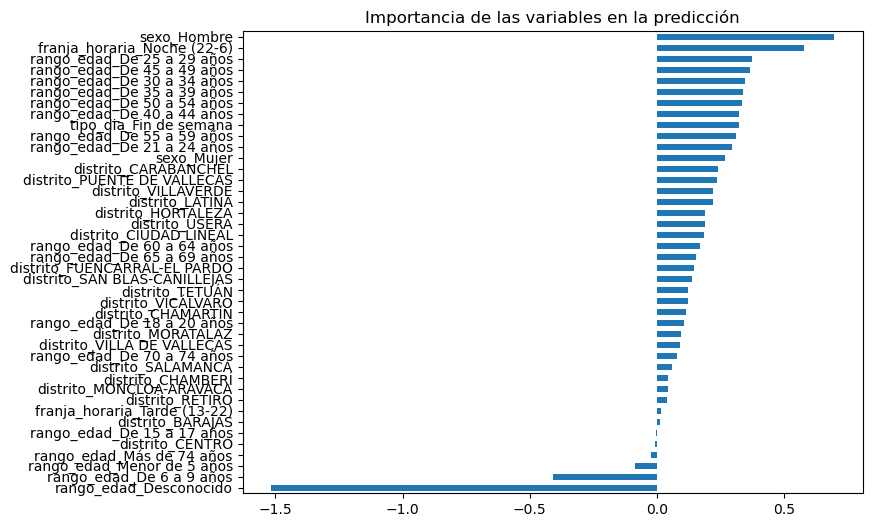

In [ ]:
"""Creamos una gráfica para visualizar los resultados"""
coeficientes.plot(kind="barh", figsize=(8,6))
plt.title("Importancia de las variables en la predicción")
plt.show()

Tal y como habíamos previsto en el EDA, el sexo y la franja horaria influyen en la posibilidad de que un implicado de positivo en alcoholemia, siendo la noche y los hombres los los que tienen mayor probabilidad de dar positivo. Así como otras variables como el rango de edad o o el tipo de dia, viendo que, por ejemplo, si es fin de semana hay más posibilidades de dar positivo.
